# Normalization is a technique often applied as part of data preparation for machine learning. The goal of normalizationn is to change the values of numeric columns in the dataset to use a common scale, without distoring differenece in the ranges of values or losing informtion.

In [1]:
# techniques are:-


#1 minmax scaling 
#2 mean normalization
#3 max absolute scale
#4 robust scale

In [2]:
#1 minmax scaling 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("Wine dataset.csv",header=None,usecols=[0,1,2])
data.columns =["class label",'Alcohol','Malic Acid']

In [4]:
data.drop(index = 0,inplace=True)

In [5]:
data.head(4)

,class label,Alcohol,Malic Acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95


In [6]:
data.dtypes

class label    object
Alcohol        object
Malic Acid     object
dtype: object

In [7]:
cols = ['Alcohol', 'class label', 'Malic Acid']

data[cols] = data[cols].apply(pd.to_numeric,errors='coerce')

C:\Users\Harsh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


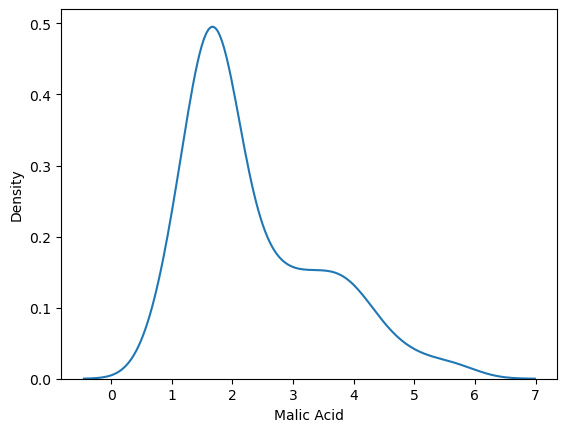

In [8]:
sns.kdeplot(data['Malic Acid'])
plt.show()

C:\Users\Harsh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


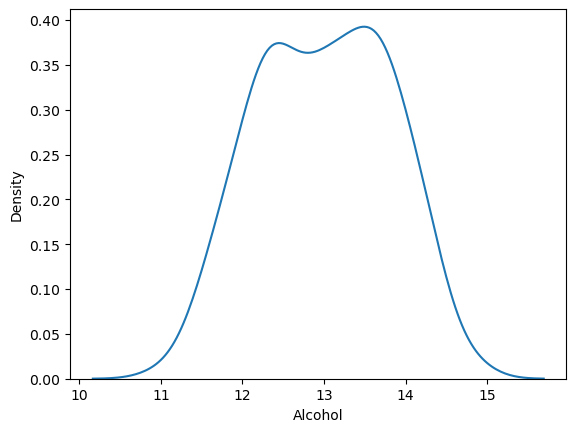

In [9]:
sns.kdeplot(data['Alcohol'])
plt.show()

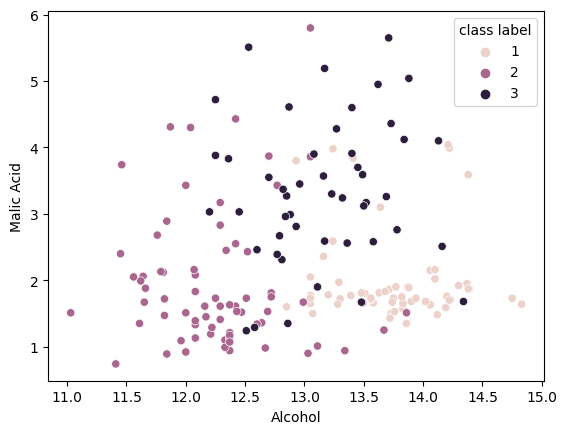

In [14]:
sns.scatterplot(x ='Alcohol',y='Malic Acid',data =data,hue="class label")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(data.drop("class label",axis=1),data['class label'],test_size=0.3,random_state=0)

X_train.shape ,X_test.shape

((124, 2), (54, 2))

In [16]:
from sklearn.preprocessing import MinMaxScaler
scale = MinMaxScaler()

In [17]:
scale.fit(X_train)

# fit the trainer to the train dataset, it will learn the parameters

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [18]:
X_train_scale = scale.transform(X_train)
X_test_scale = scale.transform(X_test)

# transfrom Train and test datasets

In [19]:
X_train_scale = pd.DataFrame(X_train_scale,columns=X_train.columns)
X_test_scale = pd.DataFrame(X_test_scale,columns=X_test.columns)

In [20]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [21]:
np.round(X_train_scale.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


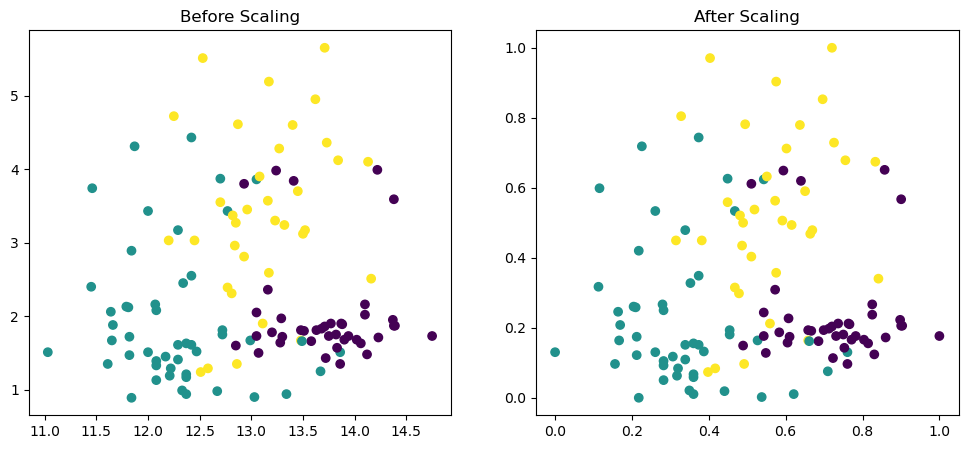

In [26]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter( X_train['Alcohol'],X_train['Malic Acid'], c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scale['Alcohol'],X_train_scale['Malic Acid'],c=y_train)
ax2.set_title("After Scaling")

plt.show()

C:\Users\Harsh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Harsh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Harsh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Harsh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

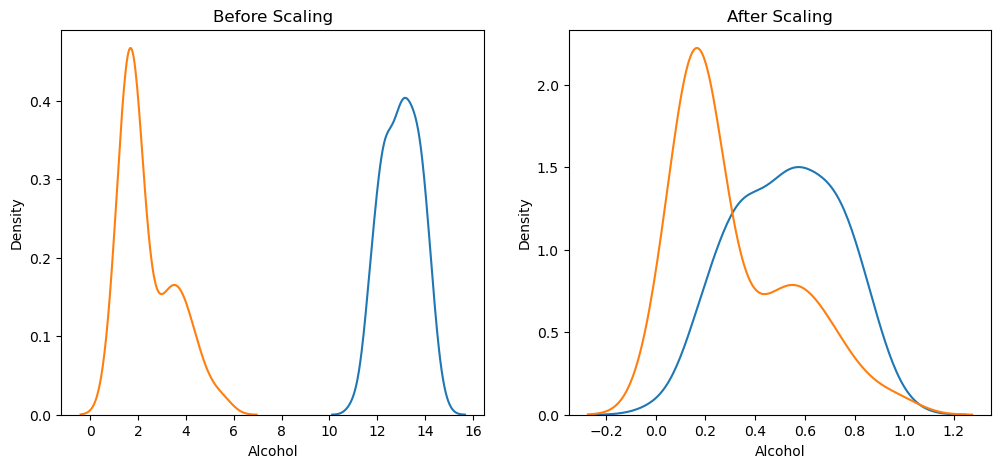

In [28]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot( X_train['Alcohol'],ax=ax1)
sns.kdeplot(X_train['Malic Acid'],ax= ax1)
ax1.set_title("Before Scaling")

sns.kdeplot(X_train_scale['Alcohol'],ax=ax2)
sns.kdeplot(X_train_scale['Malic Acid'],ax =ax2)
ax2.set_title("After Scaling")

plt.show()

# mean Normalization

## Mean normalization is a way to implement feature scaling. Mean normalization calculates and subtracts the mean for every feature. A common practice is also to divide this value by the range or the standard deviation.

# x' = (x- u(meu))  /  (max(x)- min(x))
# formula of mean Normalization

# Scale absolute
## The Max Absolute Scaler is a normalization technique that scales each feature by its maximum absolute value. This method is particularly useful when the data set contains both positive and negative values, as it preserves the sign of the data while only scaling the magnitude.

### The formula for normalization using this method is:
# X' = x/max(|X|)

## used MaxAbsScale in ml
    
    
## This technique is often used in sparse data and does not shift or center the data, which helps maintain the sparsity of the original data. It is particularly effective in scenarios where the data distribution is uneven, ensuring that the model can capture the information better.

# robust scale

## Robust scaling is a data preprocessing technique used to handle datasets with outliers effectively. Unlike standard normalization methods that rely on the mean and standard deviation, robust scaling uses the median and interquartile range (IQR), making it less sensitive to extreme values.

## RobustScaler transforms data by subtracting the median and scaling it according to the IQR, which is the range between the 25th percentile (Q1) and the 75th percentile (Q3). The formula is:

# X_scaled = (X - Q1) / (Q3 - Q1)